In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "class",
    "age",
    "sex",
    "steroid",
    "antivirals",
    "fatigue",
    "malaise",
    "anorexia",
    "liver_big",
    "liver_firm",
    "spleen_palpable",
    "spiders",
    "ascites",
    "varices",
    "bilirubin",
    "alk_phosphate",
    "sgot",
    "albumin",
    "prothrombin_time",
    "histology"
]
df = pd.read_csv('../data_raw/hepatitis/hepatitis.csv', header=None, names=columns)
df.head()

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,prothrombin_time,histology
0,2,30,2,1,2,2,2,2,1,2,2,2,2,2,1.00,85,18,4.0,?,1
1,2,50,1,1,2,1,2,2,1,2,2,2,2,2,0.90,135,42,3.5,?,1
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.70,96,32,4.0,?,1
3,2,31,1,?,1,2,2,2,2,2,2,2,2,2,0.70,46,52,4.0,80,1
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.00,?,200,4.0,?,1


In [54]:
df.shape

(155, 20)

In [55]:
# remove missing values
df = df.replace('?', np.nan)
nan_rows = df.isna().any(axis=1).sum()
print("number of rows with missing values:", nan_rows)

df.dropna(inplace=True)
print("number of rows after removing missing values:", df.shape[0])

number of rows with missing values: 75
number of rows after removing missing values: 80


In [56]:
df["class"].value_counts()

class
2    67
1    13
Name: count, dtype: int64

In [57]:
# convert binary feature labels to 0 and 1 (1 for presence of feature, 0 for absence)
binary_features = [
    "sex",
    "steroid",
    "antivirals",
    "fatigue",
    "malaise",
    "anorexia",
    "liver_big",
    "liver_firm",
    "spleen_palpable",
    "spiders",
    "ascites",
    "varices",
    "histology"]

for col in binary_features:
    df[col] = df[col].astype(int).map({1: 1, 2: 0})

df["class"] = df["class"].astype(int).map({1: 1, 2: 0})

df.head()

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,prothrombin_time,histology
5,0,34,1,0,0,0,0,0,0,0,0,0,0,0,0.90,95,28,4.0,75,1
10,0,39,1,1,1,0,0,0,1,1,0,0,0,0,1.30,78,30,4.4,85,1
11,0,32,1,0,1,1,0,0,0,1,0,1,0,0,1.00,59,249,3.7,54,1
12,0,41,1,0,1,1,0,0,0,1,0,0,0,0,0.90,81,60,3.9,52,1
13,0,30,1,0,0,1,0,0,0,1,0,0,0,0,2.20,57,144,4.9,78,1


In [58]:
for col in binary_features:
    print(df[col].value_counts())

sex
1    69
0    11
Name: count, dtype: int64
steroid
0    42
1    38
Name: count, dtype: int64
antivirals
0    59
1    21
Name: count, dtype: int64
fatigue
1    52
0    28
Name: count, dtype: int64
malaise
0    49
1    31
Name: count, dtype: int64
anorexia
0    68
1    12
Name: count, dtype: int64
liver_big
0    67
1    13
Name: count, dtype: int64
liver_firm
0    42
1    38
Name: count, dtype: int64
spleen_palpable
0    65
1    15
Name: count, dtype: int64
spiders
0    55
1    25
Name: count, dtype: int64
ascites
0    68
1    12
Name: count, dtype: int64
varices
0    70
1    10
Name: count, dtype: int64
histology
1    47
0    33
Name: count, dtype: int64


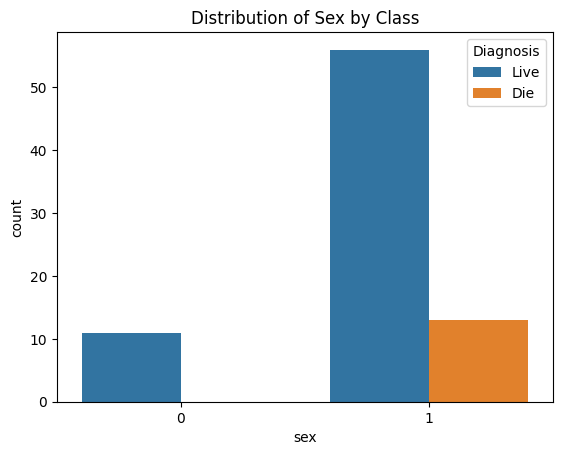

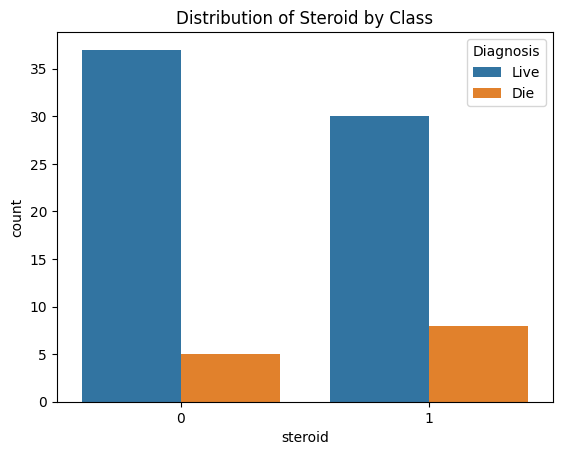

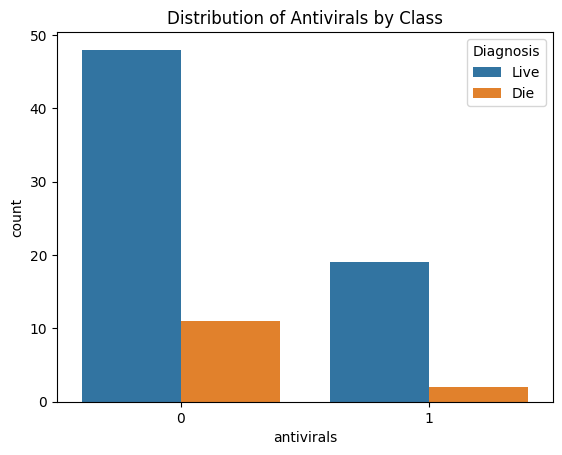

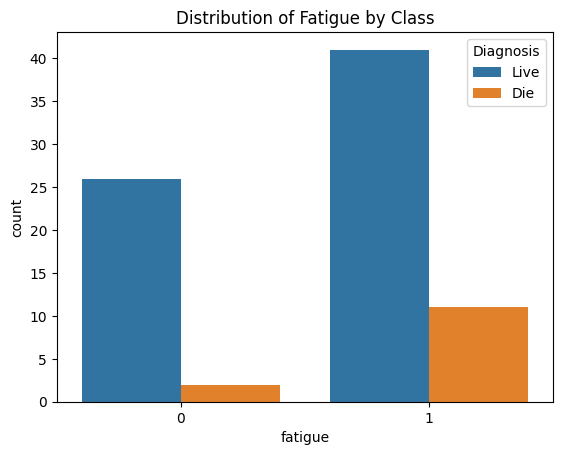

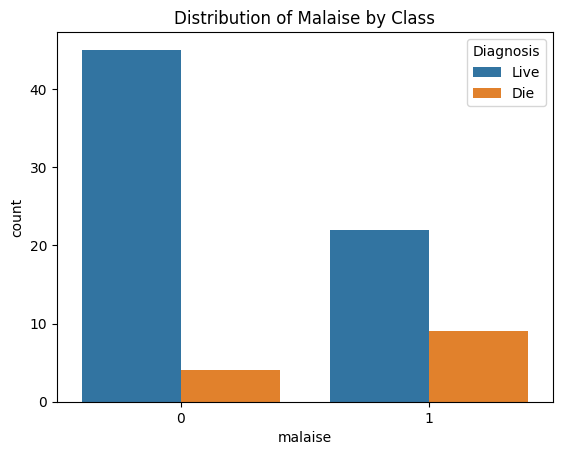

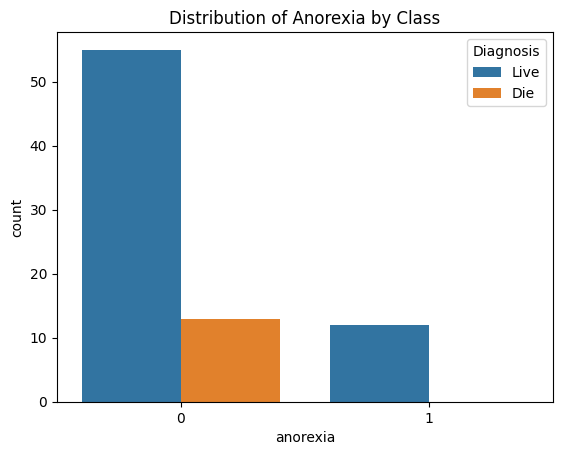

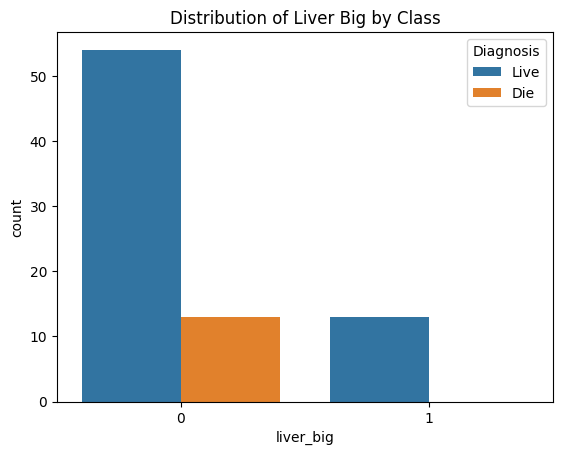

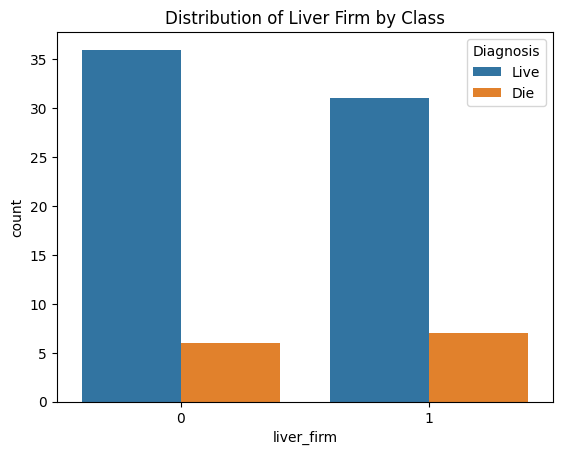

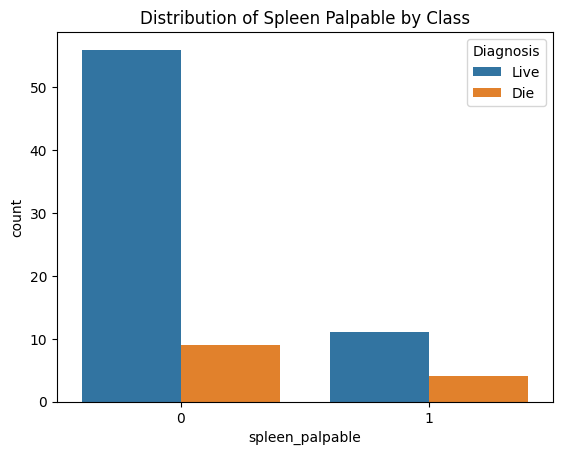

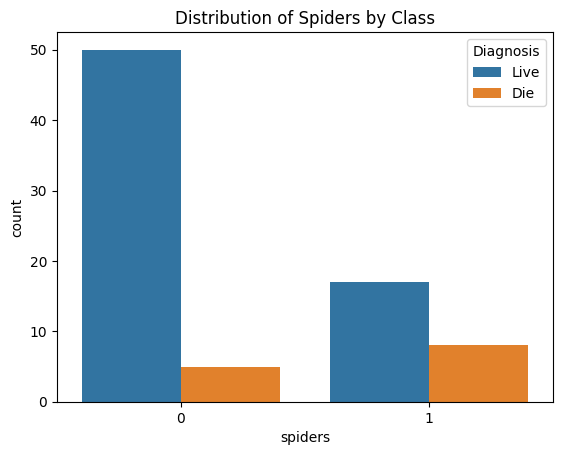

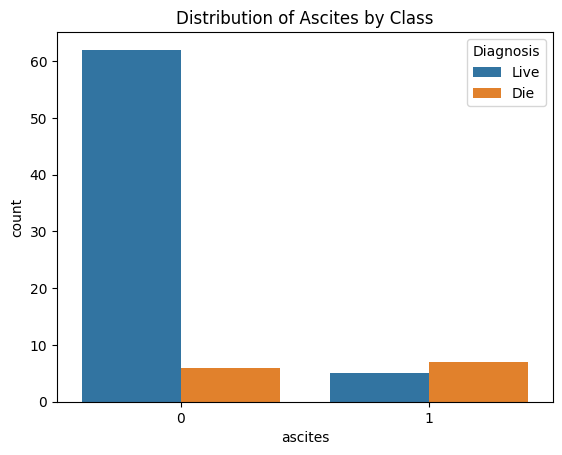

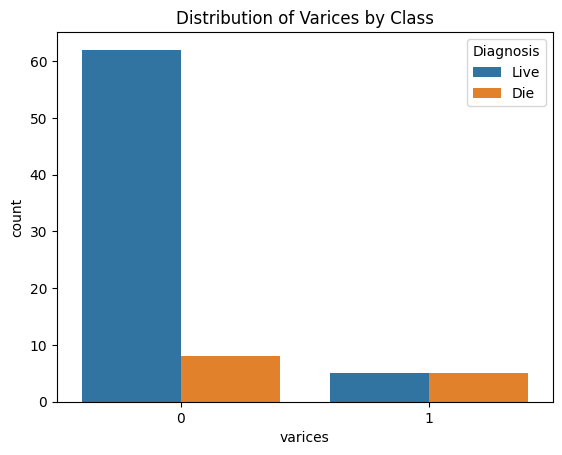

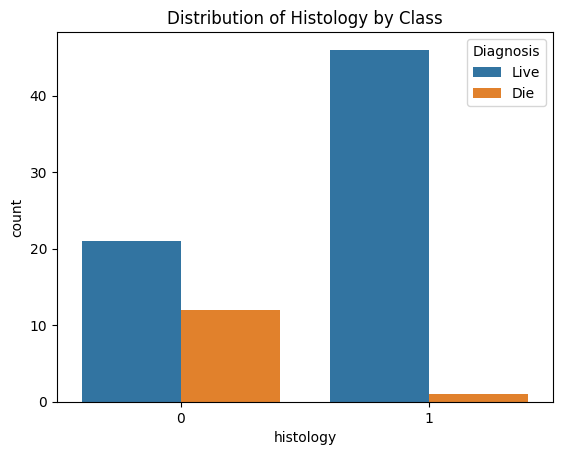

In [64]:
def format_col_name(col: str) -> str:
    col = col.replace("_", " ").title()
    return col

for col in binary_features:
    sns.countplot(x=col, hue="class", data=df)
    plt.title(f"Distribution of {format_col_name(col)} by Class")
    plt.legend(
        title="Diagnosis",
        labels=["Live", "Die"]
    )
    plt.show()

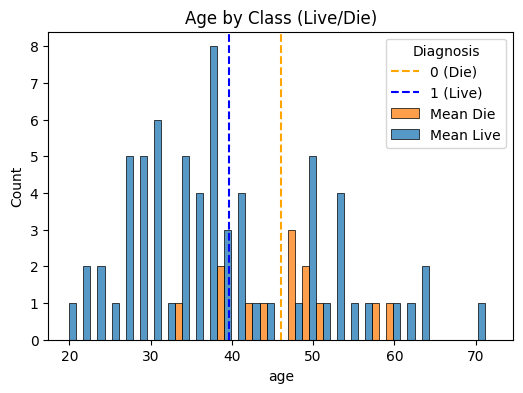

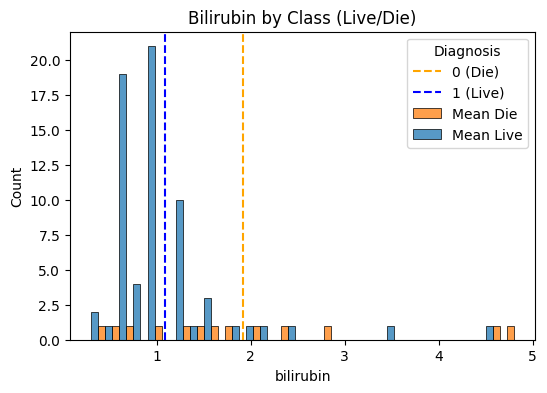

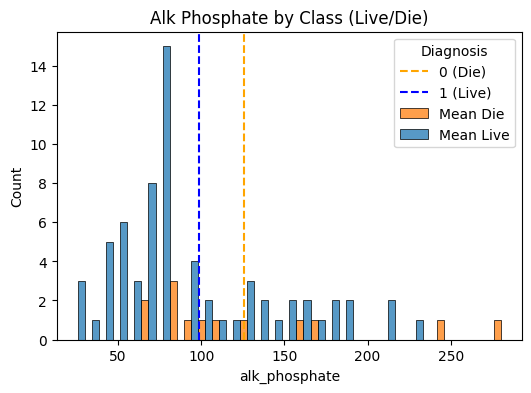

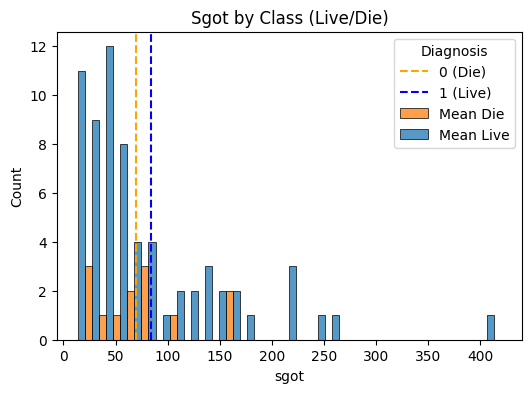

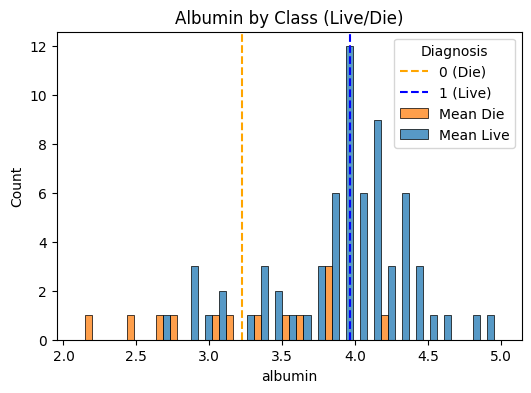

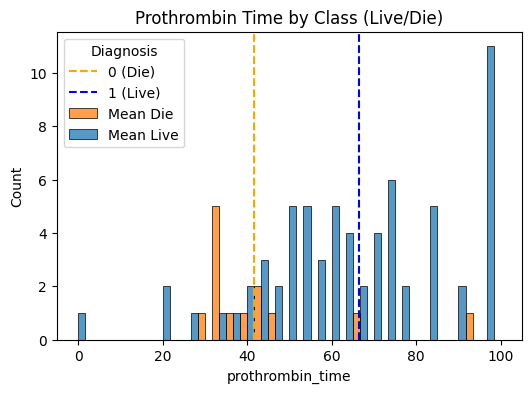

In [63]:
numeric_cols = [x for x in df.columns if x not in binary_features and x != "class"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce") 

    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        hue="class",
        multiple="dodge",
        bins=30,
        # palette={0: "green", 1: "orange"} 
    )

    mean_1 = df[df["class"] == 1][col].mean()
    mean_0 = df[df["class"] == 0][col].mean()

    plt.axvline(mean_1, color="orange", linestyle="--")
    plt.axvline(mean_0, color="blue", linestyle="--")

    plt.legend(
        title="Class",
        labels=["0 (Die)", "1 (Live)"]
    )
    plt.legend(
        title="Diagnosis",
        labels=["0 (Die)", "1 (Live)", "Mean Die", "Mean Live"]
    )

    plt.title(f"{format_col_name(col)} by Class (Live/Die)")
    plt.show()

In [61]:
df.to_csv('../data_cleaned/hepatitis.csv', index=False)